In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import numpy as np
import random


In [2]:
def fill_with_edge_color(image_path, fill_percent=0.5, fill_direction='left',rotate=True):
    # Load the image
    img = cv2.imread(image_path,cv2.IMREAD_UNCHANGED)
    #if rotate:
    #img =  cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    img = img[:, :, 0:3]
    if img is None:
        raise ValueError("Image not found or invalid format.")
    
    height, width = img.shape[:2]
    fill_percent = max(0.0, min(1.0, fill_percent))  # clamp 0–1

    if fill_direction == 'left':
        fill_width = int(width * fill_percent)
        source_col = min(fill_width, width - 1)
        column = img[:, source_col:source_col + 1]
        for col in range(fill_width):
            img[:, col:col + 1] = column

    elif fill_direction == 'right':
        fill_width = int(width * fill_percent)
        source_col = max(width - fill_width - 1, 0)
        column = img[:, source_col:source_col + 1]
        for col in range(width - fill_width, width):
            img[:, col:col + 1] = column

    elif fill_direction == 'up':
        fill_height = int(height * fill_percent)
        source_row = min(fill_height, height - 1)
        row = img[source_row:source_row + 1, :]
        for row_idx in range(fill_height):
            img[row_idx:row_idx + 1, :] = row

    elif fill_direction == 'down':
        fill_height = int(height * fill_percent)
        source_row = max(height - fill_height - 1, 0)
        row = img[source_row:source_row + 1, :]
        for row_idx in range(height - fill_height, height):
            img[row_idx:row_idx + 1, :] = row

    else:
        raise ValueError("fill_direction must be one of: 'left', 'right', 'up', 'down'.")


    return img

In [43]:

out_folder = "../filters-results/imgs_plants_mod"
if not os.path.isdir(out_folder):
    os.mkdir(out_folder)

In [ ]:
IMG_3594.JPG

../filters-results/imgs/IMG_3594.JPG


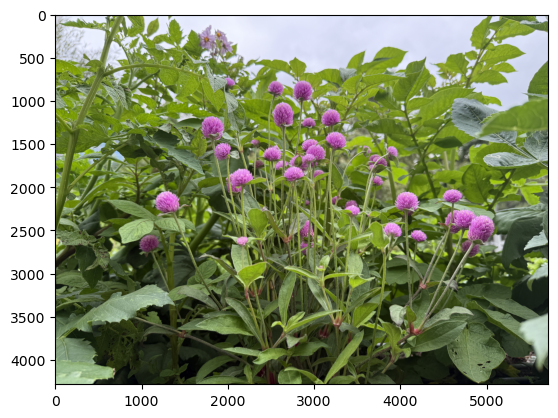

In [9]:
#imgs_folder = "imgs_plants"
imgs_folder = "../filters-results/imgs"
f = "IMG_3594.JPG"
i = os.path.join(imgs_folder,f)
print(i)
img = cv2.imread(i)
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

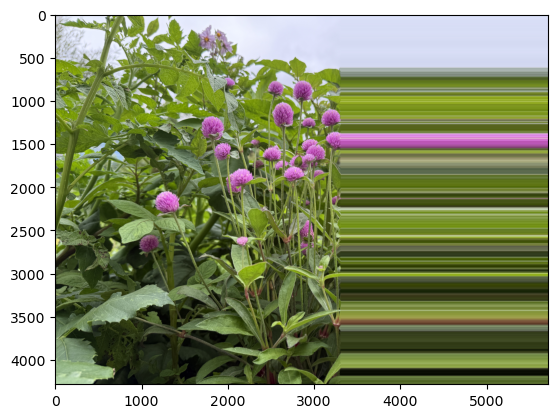

In [35]:

hf = fill_with_edge_color(i,.42,'right')
hf_rgb = cv2.cvtColor(hf,cv2.COLOR_BGR2RGB)
plt.imshow(hf_rgb)



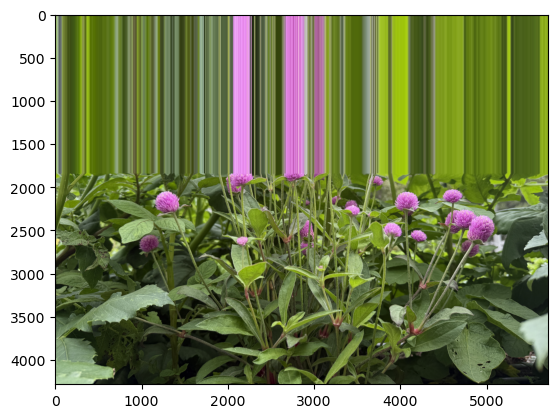

In [31]:

hf = fill_with_edge_color(i,.43,'up')
hf_rgb = cv2.cvtColor(hf,cv2.COLOR_BGR2RGB)
plt.imshow(hf_rgb)

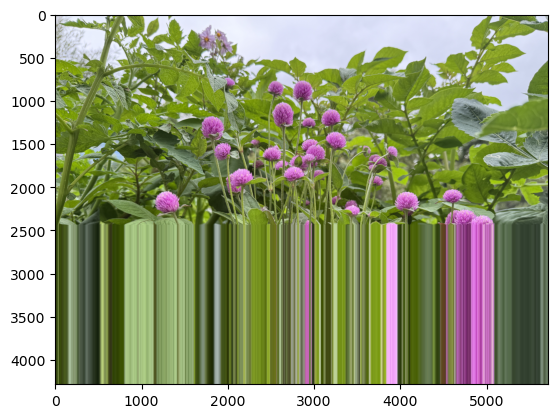

In [23]:

hf = fill_with_edge_color(i,.43,'down')
hf_rgb = cv2.cvtColor(hf,cv2.COLOR_BGR2RGB)
plt.imshow(hf_rgb)

In [37]:
o = os.path.join(out_folder, "hf2" + f )
cv2.imwrite(o,hf)

True

In [39]:
o

'imgs_plants_mod/hf2IMG_3594.JPG'